In [1]:
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
from xgboost import XGBClassifier

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
from scipy.special import logit

RANDOM_SEED = 694973

In [2]:
features = ['distance_mm', 'angle_mm']
df=pd.read_csv('input/data_model.csv')
bart_mm_scaler = joblib.load('minmax_scaler.pkl')

X_train = df.loc[df['is_train']==1][['distance_mm','angle_mm']].values
X_test = df.loc[df['is_train']!=1][['distance_mm','angle_mm']].values
y_train=df.loc[df['is_train']==1]['is_made'].values
y_test=df.loc[df['is_train']!=1]['is_made'].values

In [3]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds)
    binary_preds = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

In [4]:
model = XGBClassifier(
    eval_metric='logloss',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [5]:
train_probs = model.predict_proba(X_train)[:, 1]
train_score = compute_scores(y_train, train_probs)
print("Train Log Loss:", train_score[0])
print("Train AUC:", train_score[1])
print("Train Accuracy:", train_score[2])

Train Log Loss: 0.6460343255470736
Train AUC: 0.6610443207997035
Train Accuracy: 0.6253277670949984


In [6]:
test_probs = model.predict_proba(X_test)[:, 1]
test_score = compute_scores(y_test, test_probs)
print("Test Log Loss:", test_score[0])
print("Test AUC:", test_score[1])
print("Test Accuracy:", test_score[2])

Test Log Loss: 0.654155664622279
Test AUC: 0.6369701461203903
Test Accuracy: 0.6192507128334075


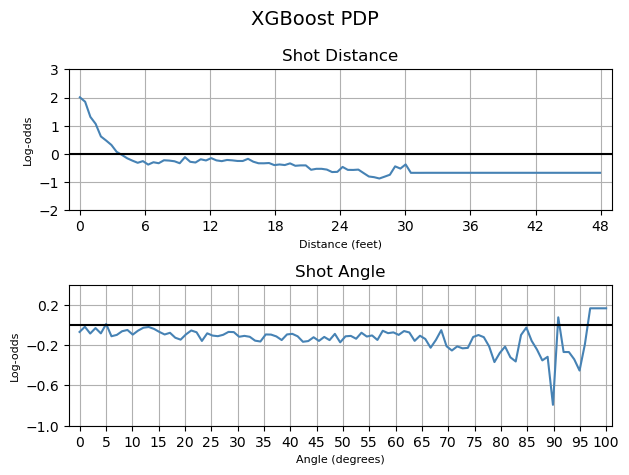

In [7]:
display = PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_train,
    features=[0, 1],
    feature_names=features,
    percentiles=(0, 1),
    response_method="predict_proba",
    random_state=RANDOM_SEED
)

fig, axes = plt.subplots(2, 1, figsize=(6.4, 4.8))
feature_labels = ["Distance (feet)", "Angle (degrees)"]
xlims = [(-1, 49), (-2, 101)]
xticks = [np.arange(0, 54, 6), np.arange(0, 101, 5)]
ylims = [(-2, 3), (-1, 0.4)]
yticks = [np.arange(-2, 4, 1), np.arange(-1, 0.6, 0.4)]
titles = ["Shot Distance", "Shot Angle"]

for i, ax in enumerate(axes):
    grid = display.pd_results[i]["grid_values"][0]
    avg = display.pd_results[i]["average"][0]
    avg_logit = logit(np.clip(avg, 1e-6, 1 - 1e-6))

    sims = np.zeros((len(grid), X_train.shape[1]))
    sims[:, i] = grid
    data_og_scale = bart_mm_scaler.inverse_transform(sims)[:, i]

    ax.plot(data_og_scale, avg_logit, color="steelblue")
    ax.axhline(0, color="black")
    ax.set_xlabel(feature_labels[i], fontsize=8)
    ax.set_ylabel("Log-odds", fontsize=8)
    ax.set_title(titles[i])
    ax.set_xlim(xlims[i])
    ax.set_xticks(xticks[i])
    ax.set_ylim(ylims[i])
    ax.set_yticks(yticks[i])
    ax.grid(True) 

plt.close(display.figure_)
plt.suptitle("XGBoost PDP", fontsize=14)
plt.tight_layout()

In [8]:
dunks = df.loc[(df['is_train']==1)&(df['shot_type']=='DUNK')]
print(np.mean(dunks['is_made']))

jumpers = df.loc[(df['is_train']==1)&(df['shot_type']=='JUMPER')]
print(np.mean(jumpers['is_made']))

hooks = df.loc[(df['is_train']==1)&(df['shot_type']=='HOOK')]
print(np.mean(hooks['is_made']))

layups = df.loc[(df['is_train']==1)&(df['shot_type']=='LAYUP')]
print(np.mean(layups['is_made']))

0.8826980994911205
0.39355227533181447
0.48329555533655266
0.5629244637023899


In [9]:
test_probs.min(), test_probs.max()

(np.float32(0.046213977), np.float32(0.9225554))

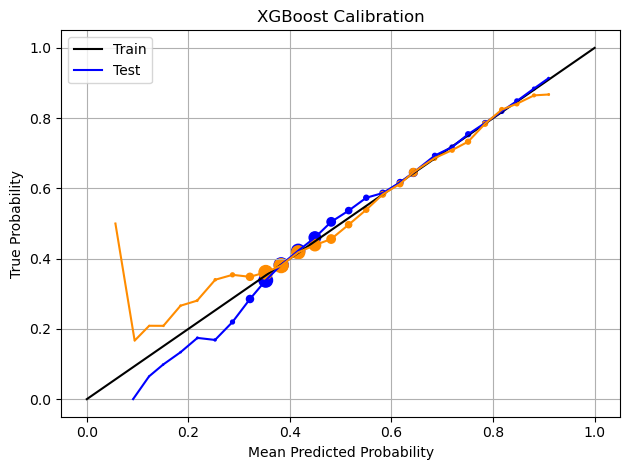

In [10]:
from sklearn.calibration import calibration_curve

def plot_cali_curve(truth, probs, label, color, nbins=30):
    prob_true, prob_pred = calibration_curve(truth, probs, n_bins=nbins)
    bindf = pd.DataFrame({'truth':truth, 'prob': probs})
    bin_edge = np.linspace(0, 1, nbins + 1)
    bindf['bin'] = pd.cut(bindf['prob'], bins=bin_edge)
    bin_counts = bindf.groupby('bin', observed=True).size().values
    plt.plot(prob_pred, prob_true, color=color, label=label)
    dot_sze = (bin_counts / bin_counts.max())*100
    plt.scatter(prob_pred, prob_true, color=color, s=dot_sze)

plt.plot([0, 1], [0, 1], color='black')
plot_cali_curve(y_train, train_probs, "Train", "blue")
plot_cali_curve(y_test, test_probs, "Test", "darkorange")
plt.title("XGBoost Calibration")
plt.ylabel("True Probability")
plt.xlabel("Mean Predicted Probability")
plt.legend(["Train", "Test"], loc="upper left")
plt.grid(True)
plt.tight_layout()

In [11]:
features = ['distance_mm', 'angle_mm']
df=pd.read_csv('input/data_model.csv')
bart_mm_scaler = joblib.load('minmax_scaler.pkl')

X_train = df.loc[df['is_train']==1][['distance_mm','angle_mm']].values
X_test = df.loc[df['is_train']!=1][['distance_mm','angle_mm']].values
y_train=df.loc[df['is_train']==1]['shot_type_idx'].values -1
y_test=df.loc[df['is_train']!=1]['shot_type_idx'].values -1

In [12]:
param_grid = {
    'n_estimators': [100],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.1, 0.2],
}

model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [13]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [14]:
grid_search.best_params_

{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}

In [15]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds, multi_class='ovr', average='weighted')
    binary_preds = np.argmax(preds, axis=1)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

In [16]:
test_probs = best_model.predict_proba(X_test)
test_score = compute_scores(y_test, test_probs)
print("Test Log Loss:", test_score[0])
print("Test AUC:", test_score[1])
print("Test Accuracy:", test_score[2])

Test Log Loss: 0.3497436026725777
Test AUC: 0.9687511486836351
Test Accuracy: 0.8675393111081702


In [17]:
bart_mm_scaler = joblib.load('minmax_scaler.pkl')
dist_grid  = np.linspace(0, 65, 100)
angle_grid = np.linspace(0, 100, 100)
dist_mesh, angle_mesh = np.meshgrid(dist_grid, angle_grid)

grid_points = np.column_stack([dist_mesh.ravel(), angle_mesh.ravel()])
grid_scaled = bart_mm_scaler.transform(grid_points)
grid_df = pd.DataFrame(grid_scaled, columns=['distance_mm','angle_mm'])


/home/jr/anaconda3/envs/pie/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [18]:
y_pred = best_model.predict(grid_df) + 1

In [19]:
grid_df['shot_type_idx'] = y_pred

In [20]:
grid_df

,distance_mm,angle_mm,shot_type_idx
0,0.000000,0.000000,2
1,0.013694,0.000000,2
2,0.027388,0.000000,2
3,0.041083,0.000000,2
4,0.054777,0.000000,2
...,...,...,...
9995,1.300953,1.000182,1
9996,1.314647,1.000182,1
9997,1.328341,1.000182,1
9998,1.342036,1.000182,1


In [21]:
grid_df.to_csv('output/grid_shot_type_pred.csv', index=False)